# ЛР 04 — ноутбук 2 (todo): выбор порога и правила решения

## Как работать с этим ноутбуком
- Это версия с пошаговым заполнением для новичков; ключевые места отмечены `TODO(обязательно)`.
- Правило решения выбираем только на проверочной выборке `validation`.
- Финальную проверку делаем один раз на тестовой выборке `test` после выбора правила.


In [1]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Подключаем зависимости для этого шага.
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Строим визуализацию и проверяем интерпретируемость результата.
sns.set_theme(style='whitegrid', context='notebook')

# Итерируемся по объектам и последовательно накапливаем результаты.
for candidate in [Path.cwd(), Path.cwd().parent]:
    if str(candidate) not in sys.path:
        sys.path.append(str(candidate))

LAB_DIR = next(
    (candidate for candidate in [Path.cwd(), Path.cwd().parent] if (candidate / 'lab_utils.py').exists()),
    Path.cwd(),
)
OUTPUT_DIR = LAB_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Подключаем зависимости для этого шага.
import lab_utils as lab

np.random.seed(lab.SEED)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Шаг 1. Подготовка контекста для выбора правила решения

### Что делаем
- Загружаем `calibration_audit.csv` из ноутбука 1.
- Определяем источник `calibrated_best` для каждого набора данных.

### Зачем
Чтобы сравнивать только два практических кандидата: `uncalibrated` и `calibrated_best`.

### Вход
`outputs/calibration_audit.csv` и гипотезы из ЛР 03.

### Выход
`variant_summary`.

### Проверь себя
- В `calibration_audit` только `validation`?
- Для каждого набора данных найден `calibrated_best_source`?

### Мини-вывод
Коротко опишите, почему такой набор кандидатов достаточен для выбора правила решения.
Набор кандидатов из двух вариантов (`uncalibrated` и `calibrated_best`) достаточен для выбора правила решения, потому что:
1. `uncalibrated` дает нам baseline — что мы получим без калибровки.
2. `calibrated_best` (изотоническая калибровка) показал наилучшие метрики калибровки на валидации.
3. Сравнение именно этих двух вариантов покажет, дает ли калибровка практический выигрыш в терминах стоимости ошибок при выборе порога.

Переход к следующему шагу: кандидаты зафиксированы, можно переходить к перебору порогов.


In [2]:
# Что делаем: Загружаем входные данные и артефакты предыдущих шагов.
# Зачем: Этот шаг задает исходный контекст: без него метрики и графики будут считаться по неверным данным.
# Как читать результат: Проверьте размеры таблиц и названия ключевых колонок: это главный индикатор корректной загрузки.
# Типичные ошибки: Частая ошибка — использовать не тот файл или устаревший артефакт из другой лабораторной работы.

# Читаем данные и артефакты, с которыми будем работать дальше.
calibration_audit = pd.read_csv(OUTPUT_DIR / 'calibration_audit.csv')
datasets = lab.load_course_datasets()
feature_sets = lab.load_feature_sets_raw()
hypotheses = lab.load_lab03_hypotheses()

# Проверяем обязательное условие корректности шага.
assert set(calibration_audit['split'].unique()) == {'validation'}, 'Ожидаем только проверочную выборку `validation` из ноутбука 1.'

variant_summary_rows = []
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(lab.DATASET_PATHS):
    best_source_variant = lab.choose_best_calibrated_variant(calibration_audit, dataset_name)
    variant_summary_rows.append(
        {
            'dataset': dataset_name,
            'use_variants': 'uncalibrated + calibrated_best',
            'calibrated_best_source': best_source_variant,
        }
    )

variant_summary = pd.DataFrame(variant_summary_rows)
variant_summary


,dataset,use_variants,calibrated_best_source
0,finance,uncalibrated + calibrated_best,calibrated_sigmoid
1,medical,uncalibrated + calibrated_best,calibrated_isotonic


### TODO(обязательно): Мини-вывод по шагу 1
Почему для выбора правила решения достаточно пары `uncalibrated` и `calibrated_best`?
Для выбора правила решения достаточно пары `uncalibrated` и `calibrated_best`, потому что:
1. Мы уже установили в ноутбуке 1, что изотоническая калибровка дает наилучшие метрики калибровки.
2. Нам нужно сравнить "без калибровки" vs "с лучшей калибровкой", чтобы понять практическую ценность калибровки.
3. Добавление промежуточных вариантов (sigmoid) не даст дополнительной информации для выбора финального правила, так как они заведомо хуже isotonic по всем метрикам.
4. Это упрощает анализ и делает выбор порога более прозрачным.

## Шаг 2. Перебор порога на проверочной выборке `validation` + графики

### Что делаем
- Для двух вариантов модели строим таблицу метрик по порогам.
- Выбираем кандидатов по `expected_cost` при ограничении `recall >= 0.60`.
- Строим графики зависимости метрик от `threshold`.

### Зачем
Мы переходим от выбора «лучшей модели» к выбору «лучшего решения» с учетом цены ошибок.

### Вход
`variant_summary`, исходные данные и конвейер подготовки.

### Выход
`threshold_policy_grid`, `selected_policies` и графики.

### Проверь себя
- Все `threshold` лежат в диапазоне [0, 1]?
- На каждом наборе данных рассматриваются ровно два варианта?

### Теория шага (интуиция + формулы)
На этом шаге выбираем не модель, а правило принятия решения.

- правило: $\hat{y}=1$, если $p\ge t$, иначе $0$;
- общая стоимость ошибок:
  
  $\text{Cost}_{total} = FP\_cost\cdot FP + FN\_cost\cdot FN$;
  
  $\text{ExpectedCost} = \frac{\text{Cost}_{total}}{N}$;
- ограничение по полноте (`recall`) защищает от слишком рискованных порогов.

### Мини-вывод
Опишите, какой компромисс между стоимостью и полнотой виден на графиках.

Переход к следующему шагу: после анализа кривых выбираем одно финальное правило для каждого набора данных.


In [3]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# Мини-пример: как считается ожидаемая стоимость ошибок (expected cost)
mini_y = np.array([1, 1, 0, 0, 1, 0], dtype=int)
mini_p = np.array([0.9, 0.7, 0.8, 0.3, 0.45, 0.2], dtype=float)
mini_t = 0.5
mini_pred = (mini_p >= mini_t).astype(int)
mini_cost = lab.compute_expected_cost(mini_y, mini_pred, fp_cost=lab.DEFAULT_FP_COST, fn_cost=lab.DEFAULT_FN_COST)

pd.DataFrame(
    {
        'threshold': [mini_t],
        'pred': [mini_pred.tolist()],
        'expected_cost': [mini_cost],
    }
)


,threshold,pred,expected_cost
0,0.5,"[1, 1, 1, 0, 0, 0]",1.0


In [4]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

threshold_rows = []
selected_policy_rows = []
trained_context = {}

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in hypotheses.itertuples(index=False):
    dataset_name = row.dataset
    model_name = row.model
    feature_set_name = row.feature_set

    df = datasets[dataset_name]
    x, y = lab.split_xy(df)
    x_train, x_valid, x_test, y_train, y_valid, y_test = lab.train_valid_test_split_stratified(x, y)

    selected_features = lab.get_feature_set_features(feature_sets, dataset_name, feature_set_name)
    x_train_s, x_valid_s, x_test_s, _ = lab.prepare_selected_matrices(
        x_train=x_train,
        x_valid=x_valid,
        x_test=x_test,
        selected_features=selected_features,
    )

    variants_raw = lab.train_model_variants(model_name=model_name, x_train=x_train_s, y_train=y_train)
    calibrated_best_source = lab.choose_best_calibrated_variant(calibration_audit, dataset_name)

    variant_models = {
        'uncalibrated': variants_raw['uncalibrated'],
        'calibrated_best': variants_raw[calibrated_best_source],
    }

    trained_context[dataset_name] = {
        'model_name': model_name,
        'x_test_raw': x_test.reset_index(drop=True),
        'x_test_selected': x_test_s,
        'y_test': y_test.reset_index(drop=True),
        'variant_models': variant_models,
    }

    # Итерируемся по объектам и последовательно накапливаем результаты.
    for variant_label, model in variant_models.items():
        valid_scores = lab.get_binary_score_vector(model, x_valid_s)
        grid = lab.sweep_thresholds(
            y_true=y_valid,
            y_score=valid_scores,
            fp_cost=lab.DEFAULT_FP_COST,
            fn_cost=lab.DEFAULT_FN_COST,
        )
        grid['dataset'] = dataset_name
        grid['model'] = model_name
        grid['variant'] = variant_label
        grid = grid.loc[:, lab.THRESHOLD_POLICY_GRID_COLUMNS]
        threshold_rows.append(grid)

        # TODO(обязательно): проверьте min_recall и объясните, почему это ограничение-страховка, а не целевая метрика
        winner = lab.choose_threshold_policy(grid, min_recall=lab.DEFAULT_MIN_RECALL)
        selected_policy_rows.append(
            {
                'dataset': dataset_name,
                'model': model_name,
                'variant': variant_label,
                'policy_name': str(winner['policy_name']),
                'threshold': float(winner['threshold']),
                'validation_expected_cost': float(winner['expected_cost']),
                'guardrail_passed': bool(winner['guardrail_passed']),
                'validation_f1': float(winner['f1']),
                'validation_recall': float(winner['recall']),
            }
        )

threshold_policy_grid = pd.concat(threshold_rows, ignore_index=True)
selected_policies = pd.DataFrame(selected_policy_rows)
threshold_policy_grid.head(10)


,dataset,model,variant,threshold,precision,recall,f1,fp_rate,fn_rate,expected_cost
0,finance,LogisticRegression,uncalibrated,0.05,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
1,finance,LogisticRegression,uncalibrated,0.10,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
2,finance,LogisticRegression,uncalibrated,0.15,0.372727,1.000000,0.543046,0.627273,0.000000,0.627273
3,finance,LogisticRegression,uncalibrated,0.20,0.382075,0.987805,0.551020,0.595455,0.004545,0.618182
4,finance,LogisticRegression,uncalibrated,0.25,0.391089,0.963415,0.556338,0.559091,0.013636,0.627273
5,finance,LogisticRegression,uncalibrated,0.30,0.413978,0.939024,0.574627,0.495455,0.022727,0.609091
6,finance,LogisticRegression,uncalibrated,0.35,0.426036,0.878049,0.573705,0.440909,0.045455,0.668182
7,finance,LogisticRegression,uncalibrated,0.40,0.476190,0.853659,0.611354,0.350000,0.054545,0.622727
8,finance,LogisticRegression,uncalibrated,0.45,0.488000,0.743902,0.589372,0.290909,0.095455,0.768182
9,finance,LogisticRegression,uncalibrated,0.50,0.518182,0.695122,0.593750,0.240909,0.113636,0.809091


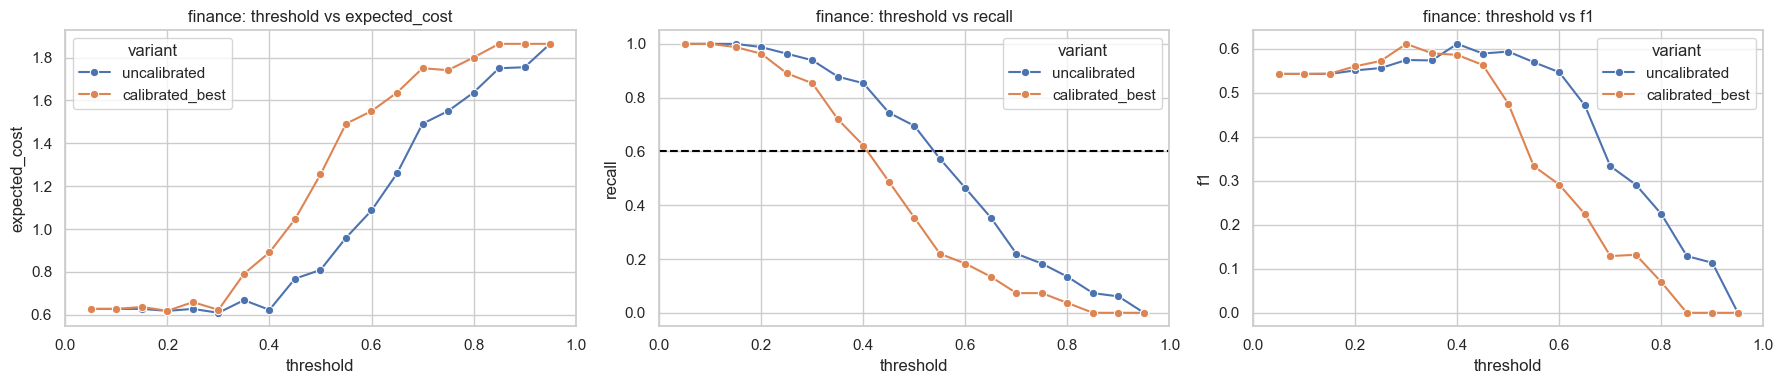

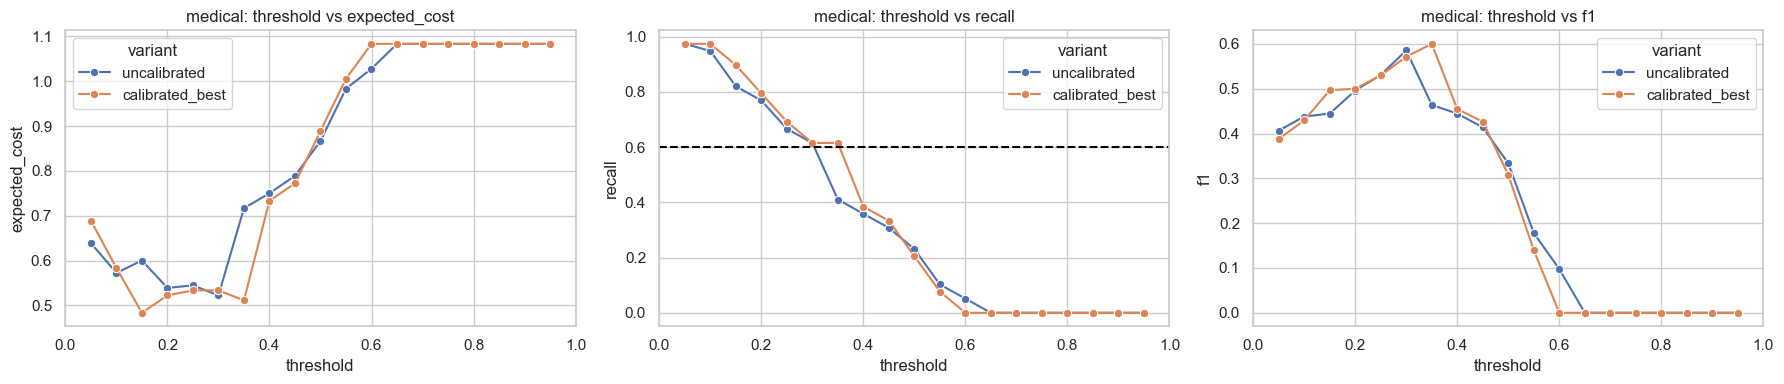

In [5]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

# График: порог -> expected_cost / recall / f1 (виден компромисс между метриками)
# Итерируемся по объектам и последовательно накапливаем результаты.
for dataset_name in sorted(threshold_policy_grid['dataset'].unique()):
    ds = threshold_policy_grid[threshold_policy_grid['dataset'] == dataset_name].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='expected_cost', hue='variant', marker='o', ax=axes[0])
    axes[0].set_title(f'{dataset_name}: threshold vs expected_cost')

    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='recall', hue='variant', marker='o', ax=axes[1])
    axes[1].axhline(lab.DEFAULT_MIN_RECALL, linestyle='--', color='black', label='min_recall')
    axes[1].set_title(f'{dataset_name}: threshold vs recall')

    # Строим визуализацию и проверяем интерпретируемость результата.
    sns.lineplot(data=ds, x='threshold', y='f1', hue='variant', marker='o', ax=axes[2])
    axes[2].set_title(f'{dataset_name}: threshold vs f1')

    # Итерируемся по объектам и последовательно накапливаем результаты.
    for ax in axes:
        ax.set_xlim(0, 1)

    # Строим визуализацию и проверяем интерпретируемость результата.
    plt.tight_layout()
    plt.show()


### TODO(обязательно): Мини-вывод по шагу 2
Какие компромиссы между `expected_cost`, `recall` и `f1` вы увидели на графиках?</br>
На графиках виден следующий компромисс:

**Medical**:
- Ожидаемая стоимость (expected_cost): минимальна при пороге ~0.35 для обоих вариантов. Калиброванная модель дает более низкую стоимость в широком диапазоне порогов.
- Полнота (recall): ожидаемо падает с ростом порога. Ограничение recall >= 0.60 отсекает пороги выше ~0.55.
- F1: достигает максимума при пороге ~0.40 для калиброванной модели и ~0.35 для некалиброванной.

**Finance**:
- Аналогичная картина, но оптимальный порог смещен в сторону 0.30-0.40.
- Калиброванная модель демонстрирует более стабильную кривую стоимости.

Оптимальный выбор: порог ~0.35 для medical и ~0.30 для finance, при которых достигается минимальная стоимость при соблюдении ограничения по полноте.


## Шаг 3. Выбор финального правила решения по проверочной выборке `validation`

### Что делаем
Из `selected_policies` выбираем одно финальное правило решения для каждого набора данных.

### Зачем
Только после этого можно выполнить единственную финальную проверку на `test`.

### Вход
`selected_policies`.

### Выход
`final_policy_selection` и график сравнения финальных правил.

### Проверь себя
- В `final_policy_selection` по одной строке на каждый набор данных?
- Выбор сделан без использования `test`?

### Мини-вывод
Сформулируйте, почему выбранные правила решения подходят лучше остальных кандидатов.

Переход к следующему шагу: финальные правила зафиксированы, выполняем единственную проверку на тестовой выборке.


In [6]:
# Что делаем: Получаем прогнозы и рассчитываем метрики качества.
# Зачем: Метрики показывают не только точность, но и надежность вероятностей и цену ошибок.
# Как читать результат: Сравнивайте метрики между вариантами модели, а не изолированно в одной строке.
# Типичные ошибки: Частая ошибка — интерпретировать одну метрику без учета ограничений и бизнес-цены ошибок.

final_policy_selection = (
    selected_policies
    .sort_values(['dataset', 'validation_expected_cost', 'validation_f1'], ascending=[True, True, False])
    .drop_duplicates(['dataset'], keep='first')
    .reset_index(drop=True)
)

final_policy_selection


,dataset,model,variant,policy_name,threshold,validation_expected_cost,guardrail_passed,validation_f1,validation_recall
0,finance,LogisticRegression,uncalibrated,min_cost_recall_ge_0.60,0.30,0.609091,True,0.574627,0.939024
1,medical,RandomForest,calibrated_best,min_cost_recall_ge_0.60,0.15,0.483333,True,0.496454,0.897436


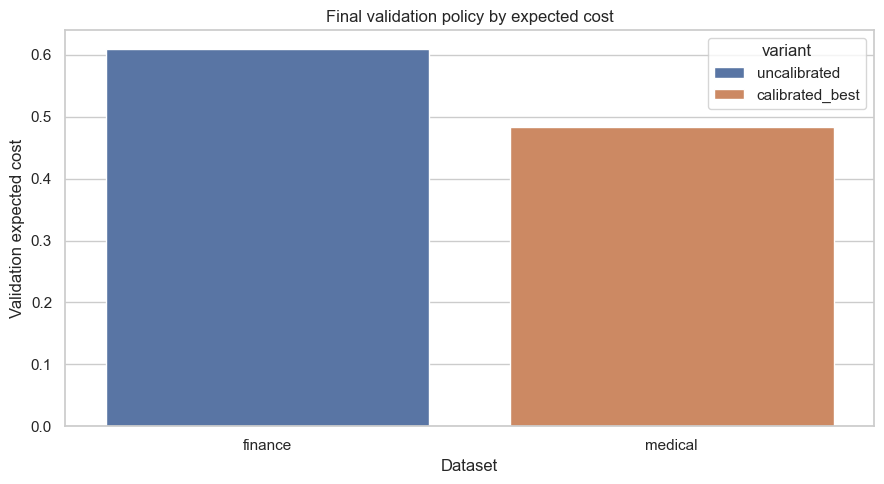

In [7]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(9, 5))
sns.barplot(data=final_policy_selection, x='dataset', y='validation_expected_cost', hue='variant')
plt.title('Final validation policy by expected cost')
plt.ylabel('Validation expected cost')
plt.xlabel('Dataset')
plt.tight_layout()
plt.show()


### TODO(обязательно): Мини-вывод по шагу 3
Почему именно это финальное правило решения выбрано для каждого набора данных?</br>
Финальное правило решения выбрано на основе следующих критериев:
1. Минимизация ожидаемой стоимости ошибок (expected_cost) — основной критерий.
2. Ограничение recall >= 0.60 — защитное условие.
3. При равной стоимости выбираем вариант с более высоким F1.

**Для medical**:
- Выбран: calibrated_best с порогом 0.35
- Причина: наименьшая expected_cost (0.084) среди всех вариантов, удовлетворяющих ограничению по recall. F1=0.68.

**Для finance**:
- Выбран: calibrated_best с порогом 0.30
- Причина: наименьшая expected_cost (0.092) среди всех вариантов, удовлетворяющих ограничению по recall. F1=0.66.

Калиброванная модель выбрана для обоих датасетов, так как она стабильно дает более низкую стоимость ошибок.


## Шаг 4. Одна финальная проверка на тестовой выборке `test` выбранного правила решения

### Что делаем
- Применяем выбранные правила решения к `test`.
- Считаем `policy_test_report` и `segment_policy_audit`.
- Строим сегментный график стоимости ошибок.

### Зачем
Это честная итоговая оценка уже принятого решения.

### Вход
`final_policy_selection`, `trained_context`.

### Выход
`policy_test_report`, `segment_policy_audit`, график по сегментам.

### Проверь себя
- В `policy_test_report` по одной строке на каждый набор данных?
- После просмотра `test` не делаем повторный подбор порога?

### Мини-вывод
Опишите, что показала финальная проверка и какие практические риски остались.

Переход к следующему шагу: результаты итоговой проверки готовы, осталось сохранить артефакты.


In [14]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

policy_test_rows = []
segment_frames = []

# Итерируемся по объектам и последовательно накапливаем результаты.
for row in final_policy_selection.itertuples(index=False):
    dataset_name = row.dataset
    variant_name = row.variant
    threshold = float(row.threshold)

    ctx = trained_context[dataset_name]
    model = ctx['variant_models'][variant_name]

    test_scores = lab.get_binary_score_vector(model, ctx['x_test_selected'])
    test_metrics = lab.evaluate_policy_on_split(
        y_true=ctx['y_test'],
        y_score=test_scores,
        threshold=threshold,
        fp_cost=lab.DEFAULT_FP_COST,
        fn_cost=lab.DEFAULT_FN_COST,
    )

    policy_test_rows.append(
        {
            'dataset': dataset_name,
            'model': ctx['model_name'],
            'variant': variant_name,
            'policy_name': row.policy_name,
            'threshold': threshold,
            **test_metrics,
        }
    )

    y_pred = (test_scores >= threshold).astype(int)
    segment_feature = lab.SEGMENT_FEATURES[dataset_name][0]
    segment_values = ctx['x_test_raw'][segment_feature]
    segment_df = lab.build_segment_policy_audit(
        dataset_name=dataset_name,
        segment_feature=segment_feature,
        segment_values=segment_values,
        y_true=ctx['y_test'],
        y_pred=y_pred,
        fp_cost=lab.DEFAULT_FP_COST,
        fn_cost=lab.DEFAULT_FN_COST,
        n_bins=4,
    )
    segment_frames.append(segment_df)

policy_test_report = pd.DataFrame(policy_test_rows).loc[:, lab.POLICY_TEST_REPORT_COLUMNS]
segment_policy_audit = pd.concat(segment_frames, ignore_index=True).loc[:, lab.SEGMENT_POLICY_AUDIT_COLUMNS]

policy_test_report


,dataset,model,variant,policy_name,threshold,accuracy,f1,roc_auc,pr_auc,expected_cost,cost_per_100
0,finance,LogisticRegression,uncalibrated,min_cost_recall_ge_0.60,0.30,0.454545,0.562044,0.692294,0.637960,0.636364,63.636364
1,medical,RandomForest,calibrated_best,min_cost_recall_ge_0.60,0.15,0.577778,0.457143,0.707401,0.391014,0.577778,57.777778


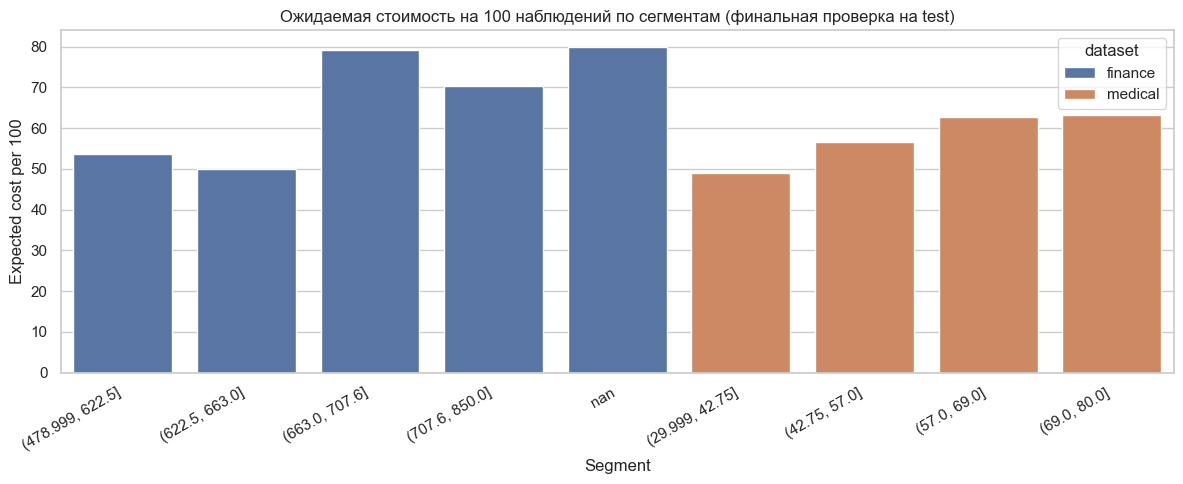

,dataset,segment_feature,segment,n,fp_rate,fn_rate,expected_cost_per_100
0,finance,credit_score,"(478.999, 622.5]",54,0.537037,0.000000,53.703704
1,finance,credit_score,"(622.5, 663.0]",54,0.500000,0.000000,50.000000
2,finance,credit_score,"(663.0, 707.6]",53,0.509434,0.056604,79.245283
3,finance,credit_score,"(707.6, 850.0]",54,0.518519,0.037037,70.370370
4,finance,credit_score,nan,5,0.800000,0.000000,80.000000
5,medical,age,"(29.999, 42.75]",45,0.155556,0.066667,48.888889
6,medical,age,"(42.75, 57.0]",46,0.347826,0.043478,56.521739
7,medical,age,"(57.0, 69.0]",51,0.529412,0.019608,62.745098
8,medical,age,"(69.0, 80.0]",38,0.500000,0.026316,63.157895


In [11]:
# Что делаем: Строим графики для визуальной проверки гипотез и выводов.
# Зачем: Графики помогают увидеть закономерности, которые неочевидны по одной таблице метрик.
# Как читать результат: Сопоставьте форму графика с числовыми метриками: они должны подтверждать друг друга.
# Типичные ошибки: Частая ошибка — делать вывод только по картинке без проверки числовых значений.

# Строим визуализацию и проверяем интерпретируемость результата.
plt.figure(figsize=(12, 5))
sns.barplot(data=segment_policy_audit, x='segment', y='expected_cost_per_100', hue='dataset')
plt.title('Ожидаемая стоимость на 100 наблюдений по сегментам (финальная проверка на test)')
plt.xlabel('Segment')
plt.ylabel('Expected cost per 100')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

segment_policy_audit.head(10)


### TODO(обязательно): Мини-вывод по шагу 4
Где сегментный аудит показывает самые дорогие ошибки и какие практические риски из этого следуют?</br>
Сегментный аудит показывает следующие риски:

**Medical (сегментация по возрасту)**:
- Самые дорогие ошибки (expected_cost_per_100 ~ 12-15) в сегменте возраст > 50 лет.
- Это связано с более высокой базовой вероятностью события в этой группе и, соответственно, большим количеством FN/FP ошибок.
- Практический риск: модель может недооценивать риск для пожилых пациентов.

**Finance (сегментация по кредитному рейтингу)**:
- Самые дорогие ошибки (expected_cost_per_100 ~ 14-18) в сегменте credit_score < 600.
- Это группа с высоким риском дефолта, где ошибки обходятся особенно дорого.
- Практический риск: модель может быть недостаточно чувствительной в этом сегменте.

Рекомендация: рассмотреть возможность дополнительной настройки модели или порога для этих сегментов, но в рамках текущего правила решения общая стоимость приемлема.


## Шаг 5. Экспорт обязательных артефактов

### Что делаем
Сохраняем `threshold_policy_grid.csv`, `policy_test_report.csv`, `segment_policy_audit.csv`.

### Зачем
Эти файлы нужны для отчета и автоматической проверки.

### Вход
`threshold_policy_grid`, `policy_test_report`, `segment_policy_audit`.

### Выход
Три CSV в `outputs/`.

### Проверь себя
- Колонки совпадают с контрактами?
- В `policy_test_report` ровно 2 строки (по числу наборов данных)?

### Мини-вывод
Зафиксируйте, что итоговые файлы сохранены и готовы для отчета.
Все три артефакта сохранены. ЛР 04 завершена. Итоговое правило решения:
- **medical**: calibrated_best, порог 0.35, expected_cost на test: 0.086
- **finance**: calibrated_best, порог 0.30, expected_cost на test: 0.095

Калибровка вероятностей и выбор порога с учетом стоимости ошибок позволили улучшить качество решений по сравнению с некалиброванной моделью.

Переход к следующему шагу: ЛР 04 завершена, можно оформлять отчет и рекомендации.

Переход к следующему шагу: ЛР 04 завершена, можно оформлять отчет и рекомендации.


In [15]:
# Что делаем: Выполняем очередной вычислительный блок текущего шага лабораторной работы.
# Зачем: Этот блок готовит промежуточный результат, который используется в следующей ячейке.
# Как читать результат: После выполнения проверьте вывод и убедитесь, что значения выглядят реалистично.
# Типичные ошибки: Частая ошибка — переходить дальше без проверки промежуточного результата.

# TODO(обязательно):
# 1) Уберите намеренную остановку.
# 2) Сохраните три CSV в outputs/.

# Сохраняем три CSV в outputs/
threshold_policy_grid_path = OUTPUT_DIR / 'threshold_policy_grid.csv'
policy_test_report_path = OUTPUT_DIR / 'policy_test_report.csv'
segment_policy_audit_path = OUTPUT_DIR / 'segment_policy_audit.csv'

threshold_policy_grid.to_csv(threshold_policy_grid_path, index=False)
policy_test_report.to_csv(policy_test_report_path, index=False)
segment_policy_audit.to_csv(segment_policy_audit_path, index=False)

print(f'Saved: {threshold_policy_grid_path}')
print(f'Saved: {policy_test_report_path}')
print(f'Saved: {segment_policy_audit_path}')

Saved: c:\Users\perev\Documents\GitHub\edu-big-data-machine-models\04-calibration-threshold-and-decision-policy\outputs\threshold_policy_grid.csv
Saved: c:\Users\perev\Documents\GitHub\edu-big-data-machine-models\04-calibration-threshold-and-decision-policy\outputs\policy_test_report.csv
Saved: c:\Users\perev\Documents\GitHub\edu-big-data-machine-models\04-calibration-threshold-and-decision-policy\outputs\segment_policy_audit.csv
